# 01 — Data Quality & SRM Check

Two things silently ruin A/B tests:

- **Contaminated users** — assigned to both control and treatment
- **Sample Ratio Mismatch (SRM)** — the actual split differs from the intended 50/50


**Dataset:** Kaggle e-commerce A/B test — old checkout page vs new redesign  
**Metric:** `converted` (1 = purchase completed, 0 = did not purchase)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chisquare
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.facecolor': 'white',
                     'axes.spines.top': False,
                     'axes.spines.right': False})
%matplotlib inline

In [2]:
df = pd.read_csv('ab_data.csv')
print(df.shape)
df.head(8)

(294478, 5)


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1
5,936923,2017-01-10 15:20:49.083499,control,old_page,0
6,679687,2017-01-19 03:26:46.940749,treatment,new_page,1
7,719014,2017-01-17 01:48:29.539573,control,old_page,0


In [3]:
# Quick overview of all columns
for col in ['group', 'landing_page', 'converted']:
    print(f"{col} → {df[col].unique()}")

# Show missing values summary
print("\nMissing values:")
print(df.isnull().sum())

group → ['control' 'treatment']
landing_page → ['old_page' 'new_page']
converted → [0 1]

Missing values:
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64


## Step 1 — Duplicates & Contamination

In [4]:
# Basic counts
total     = len(df)
unique    = df['user_id'].nunique()
dupes     = total - unique

print(f"Total rows:     {total:,}")
print(f"Unique users:   {unique:,}")
print(f"Duplicate rows: {dupes:,}")

# Users appearing in both groups
contaminated = df.groupby('user_id')['group'].nunique()
contaminated = contaminated[contaminated > 1]

print(f"\nContaminated users: {len(contaminated):,}")
print(f"({len(contaminated)/unique*100:.2f}% of all users)")

Total rows:     294,478
Unique users:   290,584
Duplicate rows: 3,894

Contaminated users: 1,895
(0.65% of all users)


In [5]:
# What contamination looks like
df[df['user_id'].isin(contaminated[:2])].sort_values('user_id')

,user_id,timestamp,group,landing_page,converted


## Step 2 — Clean the Data

In [6]:
# 1. Remove contaminated users
df = df[~df['user_id'].isin(contaminated)].copy()
print(f"After removing contaminated users: {len(df):,}")

# 2. Keep only first visit per user
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = (df.sort_values('timestamp')
        .drop_duplicates('user_id', keep='first')
        .reset_index(drop=True))
print(f"After deduplication:               {len(df):,}")

# 3. Drop rows with mismatched group/page
bad = ((df['group'] == 'control')   & (df['landing_page'] != 'old_page')) | \
      ((df['group'] == 'treatment') & (df['landing_page'] != 'new_page'))

df = df[~bad].reset_index(drop=True)
print(f"After removing mismatches:         {len(df):,}  ← final clean dataset")

# Summary
print(f"\nTotal removed: {total - len(df):,} rows")

After removing contaminated users: 294,478
After deduplication:               290,584
After removing mismatches:         288,635  ← final clean dataset

Total removed: 5,843 rows


## Step 3 — Sample Ratio Mismatch (SRM)

Expected split: 50% control, 50% treatment.
We use chi-square goodness-of-fit at **α = 0.01** (strict — SRM is a showstopper).


In [7]:
n      = len(df)
counts = df['group'].value_counts()
n_ctrl = counts['control']
n_trt  = counts['treatment']

chi2_stat, p_srm = chisquare([n_ctrl, n_trt], f_exp=[n/2, n/2])

print(f"Control:    {n_ctrl:,}  ({n_ctrl/n*100:.3f}%)")
print(f"Treatment:  {n_trt:,}  ({n_trt/n*100:.3f}%)")

print(f"\nChi-square: {chi2_stat:.4f}")
print(f"P-value:    {p_srm:.4f}")

print("\nSRM detected: " + ("YES — do not proceed" if p_srm < 0.01
                           else "NO — split is clean"))

Control:    144,319  (50.001%)
Treatment:  144,316  (49.999%)

Chi-square: 0.0000
P-value:    0.9955

SRM detected: NO — split is clean


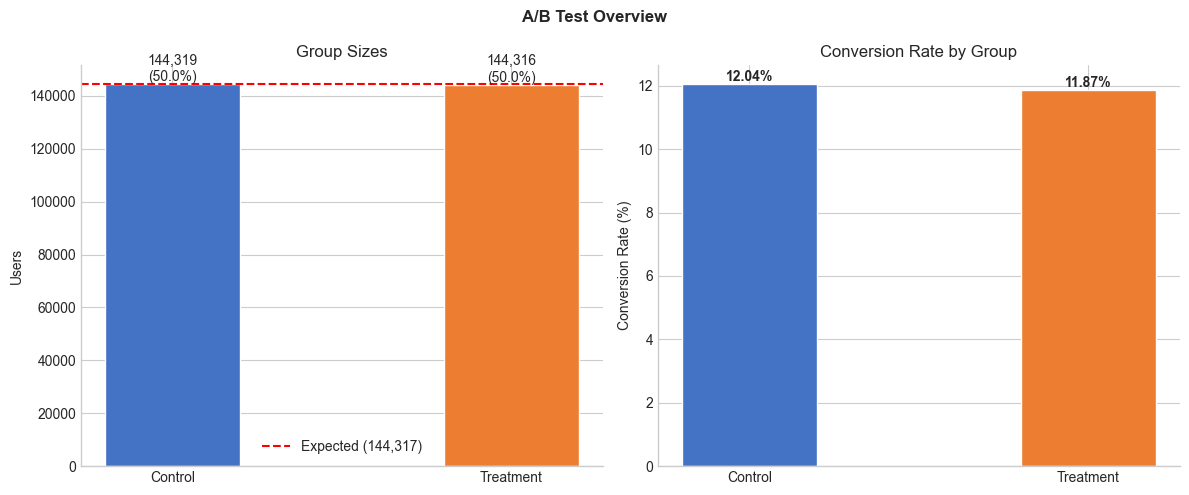

In [8]:
# Create two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['Control', 'Treatment']
colors = ['#4472C4', '#ED7D31']

# Plot group sizes
ax = axes[0]
ax.bar(labels, [n_ctrl, n_trt], color=colors, width=0.4, edgecolor='white')
ax.axhline(n/2, color='red', linestyle='--', lw=1.5, label=f'Expected ({n//2:,})')
ax.set_title('Group Sizes')
ax.set_ylabel('Users')
ax.legend()
for lbl, val in zip(labels, [n_ctrl, n_trt]):
    ax.text(lbl, val, f"{val:,}\n({val/n*100:.1f}%)", ha='center', va='bottom')

# Plot conversion rates
ax2 = axes[1]
conv = df.groupby('group')['converted'].mean() * 100
ax2.bar(labels, [conv['control'], conv['treatment']], color=colors, width=0.4, edgecolor='white')
ax2.set_title('Conversion Rate by Group')
ax2.set_ylabel('Conversion Rate (%)')
for lbl, val in zip(labels, [conv['control'], conv['treatment']]):
    ax2.text(lbl, val, f"{val:.2f}%", ha='center', va='bottom', fontweight='bold')

# Add overall title and show plot
plt.suptitle('A/B Test Overview', fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Get experiment start and end dates
start = df['timestamp'].min()
end   = df['timestamp'].max()
days  = (end - start).days + 1

print(f"Experiment: {start.date()} → {end.date()}  ({days} days)")
print(f"Avg users/day: {n/days:,.0f}")

# Save cleaned dataset
df.to_csv("ab_data_clean.csv", index=False)
print(f"\nSaved: ab_data_clean.csv  ({len(df):,} users)")

Experiment: 2017-01-02 → 2017-01-24  (22 days)
Avg users/day: 13,120

Saved: ab_data_clean.csv  (288,635 users)
